# Image Processing SoSe 2026 - Assignment - 07

### Deadline is 11.06.2024 at 11:55 a.m.

#### Students: Fabio Herrmann & Julius Böhm

Please solve the assignments together with a partner.

Make sure the code runs without errors, when clicking `Kernel` -> `Restart Kernel & Run All Cells`. Then save the notebook and upload your submission.

In [16]:
# display the plots inside the notebook
%matplotlib inline

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pylab
from skimage.data import chelsea
from skimage.color import rgb2gray
    
from numpy.fft import fft2 as numpy_fft2, ifft2 as numpy_ifft2

pylab.rcParams['figure.figsize'] = (12, 12)   # This makes the plot bigger

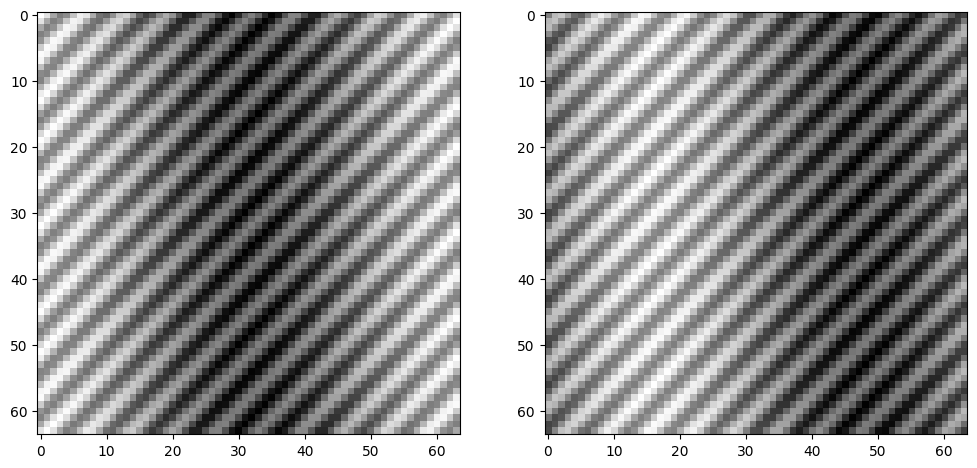

In [18]:
# Playground to get some intuition for 2d fourier transformation
ft = np.zeros((64,64))

# set some random coefficients and see what happens
ft[0, 1] = 1
ft[10, 10] = 1

plt.subplot(121)
plt.imshow(np.real(numpy_ifft2(ft)), cmap='gray')
plt.subplot(122)
plt.imshow(np.imag(numpy_ifft2(ft)), cmap='gray')
plt.show()

# Exercise 1 - 2D DFT - 2 Points
Implement the 2D Discrete Fourier Transformation with [Matrix Multiplication](https://en.wikipedia.org/wiki/DFT_matrix). You can use your code from the last assignment to compute the dft matrix.

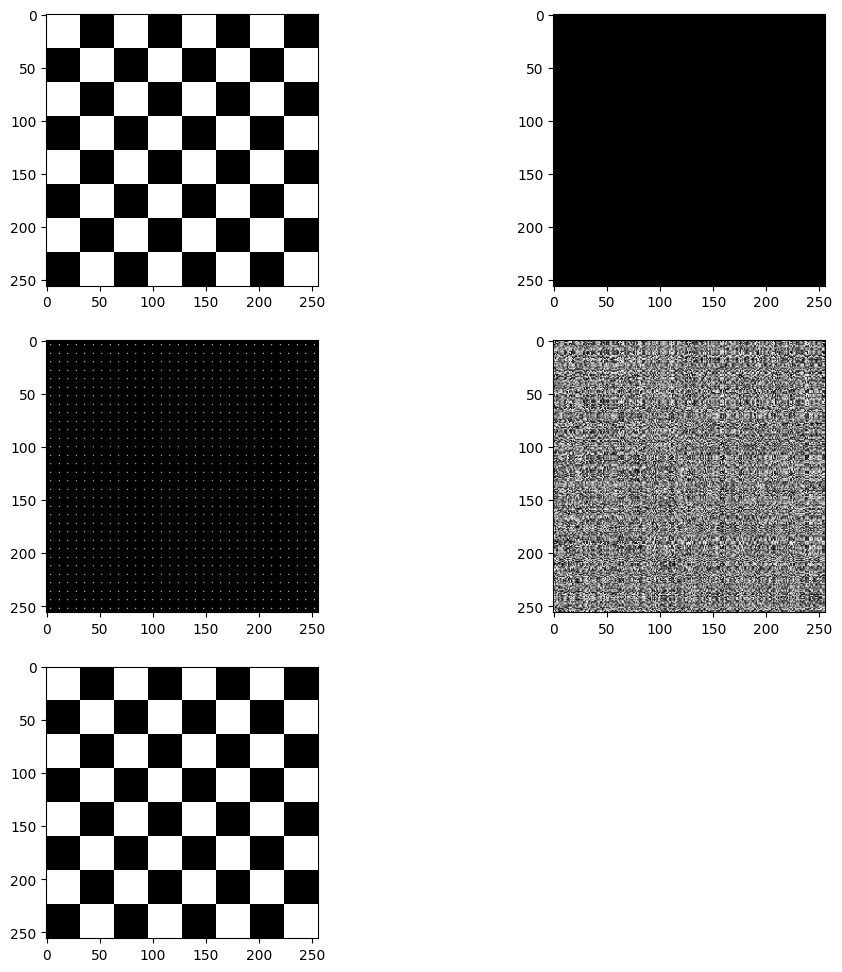

In [ ]:
def dft_matrix(n, inverse=False):
    k = np.arange(n).reshape((n, 1))
    l = np.arange(n).reshape((1, n))
    sign = 1 if inverse else -1
    W = np.exp(sign * 2j * np.pi * k * l / n)
    return W

def dft2d(img):
    """
    Returns the 2d discrete fourier transformation
    """
    img = np.asarray(img, dtype=complex)
    M, N = img.shape
    Wm = dft_matrix(M, inverse=False)  # MxM
    Wn = dft_matrix(N, inverse=False)  # NxN
    return Wm @ img @ Wn

def inv_dft2d(X):
    """
    Returns the 2d inverse discrete fourier transformation
    """
    X = np.asarray(X, dtype=complex)
    M, N = X.shape
    Wm_inv = dft_matrix(M, inverse=True)  # MxM (conjugate of forward)
    Wn_inv = dft_matrix(N, inverse=True)  # NxN
    return (Wm_inv @ X @ Wn_inv) / (M * N)


def chess_board(n=8, field_size=32):
    board = np.zeros((n*field_size, n*field_size))
    s = field_size
    for i in range(n):
        for j in range(n):
            if (i + j) % 2 == 0:
                board[i*s:(i+1)*s, j*s:(j+1)*s] = 1
    return board

plt.subplot(321)
plt.imshow(np.real(chess_board()), cmap='gray')
plt.subplot(322)
plt.imshow(np.imag(chess_board()), cmap='gray')
plt.subplot(323)
plt.imshow(np.log10(1e-9 + np.abs(dft2d(chess_board()))), cmap='gray')
plt.subplot(324)
plt.imshow(np.arctan2(np.imag(dft2d(chess_board())), np.real(dft2d(chess_board()))), cmap='gray')
plt.subplot(325)
plt.imshow(np.real(inv_dft2d(dft2d(chess_board()))), cmap='gray')
plt.show()

# Exercise 2 - High and Low Pass filter with the 2D fourier transformation - 3 Points

In [ ]:
def high_pass(img_ft, n):
    """Removes the low frequencies"""
    ft = img_ft.copy()
    ft[:n, :n] = 0
    ft[-n:, :n] = 0
    ft[-n:, -n:] = 0
    ft[:n, -n:] = 0
    return ft

def low_pass(img_ft, n):
    """Removes the high frequencies (keeps low-frequency corner blocks of size n)."""
    ft = img_ft.copy()
    M, N = ft.shape

    ft[:, :] = 0
    ft[:n, :n] = img_ft[:n, :n]
    ft[-n:, :n] = img_ft[-n:, :n]
    ft[:n, -n:] = img_ft[:n, -n:]
    ft[-n:, -n:] = img_ft[-n:, -n:]
    return ft

def band_pass(img_ft, low, high):
    """Only preserve the frequencies between low and high"""
    ft = np.zeros_like(img_ft, dtype=img_ft.dtype)
    M, N = img_ft.shape

    y = np.arange(M).reshape(M, 1)
    x = np.arange(N).reshape(1, N)
    
    d_tl = np.sqrt((y)**2 + (x)**2)
    d_tr = np.sqrt((y)**2 + (x - (N-1))**2)
    d_bl = np.sqrt((y - (M-1))**2 + (x)**2)
    d_br = np.sqrt((y - (M-1))**2 + (x - (N-1))**2)

    mask = ((d_tl >= low) & (d_tl < high)) | \
           ((d_tr >= low) & (d_tr < high)) | \
           ((d_bl >= low) & (d_bl < high)) | \
           ((d_br >= low) & (d_br < high))
    ft[mask] = img_ft[mask]
    return ft

    
def inv_dft_and_plot(img_ft):
    plt.imshow(np.real(inv_dft2d(img_ft)), cmap='gray', vmin=0, vmax=1)
    plt.show()

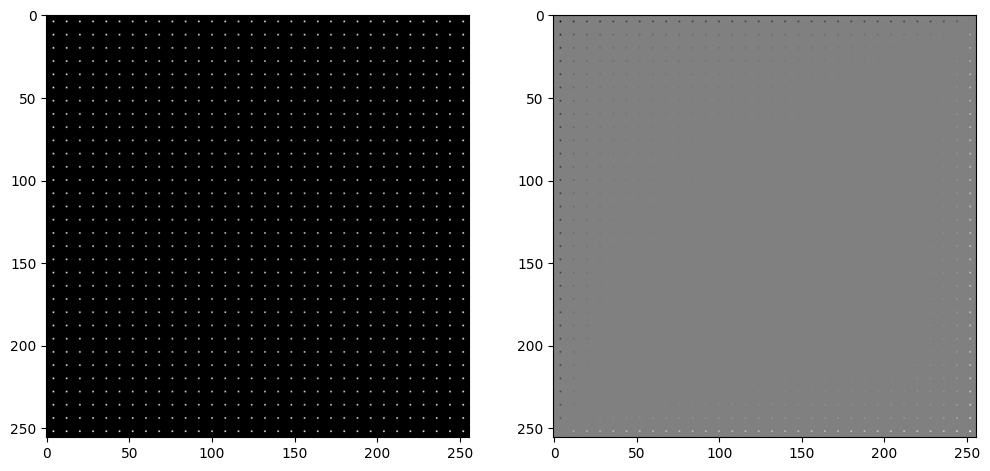

In [35]:
chess_board_ft = dft2d(chess_board())

# display frequency domain of the chess_board
plt.subplot(121)
plt.imshow(np.log10(1e-9+np.abs(np.abs(chess_board_ft))), cmap='gray')
plt.subplot(122)
plt.imshow(np.imag(chess_board_ft), cmap='gray')
plt.show()

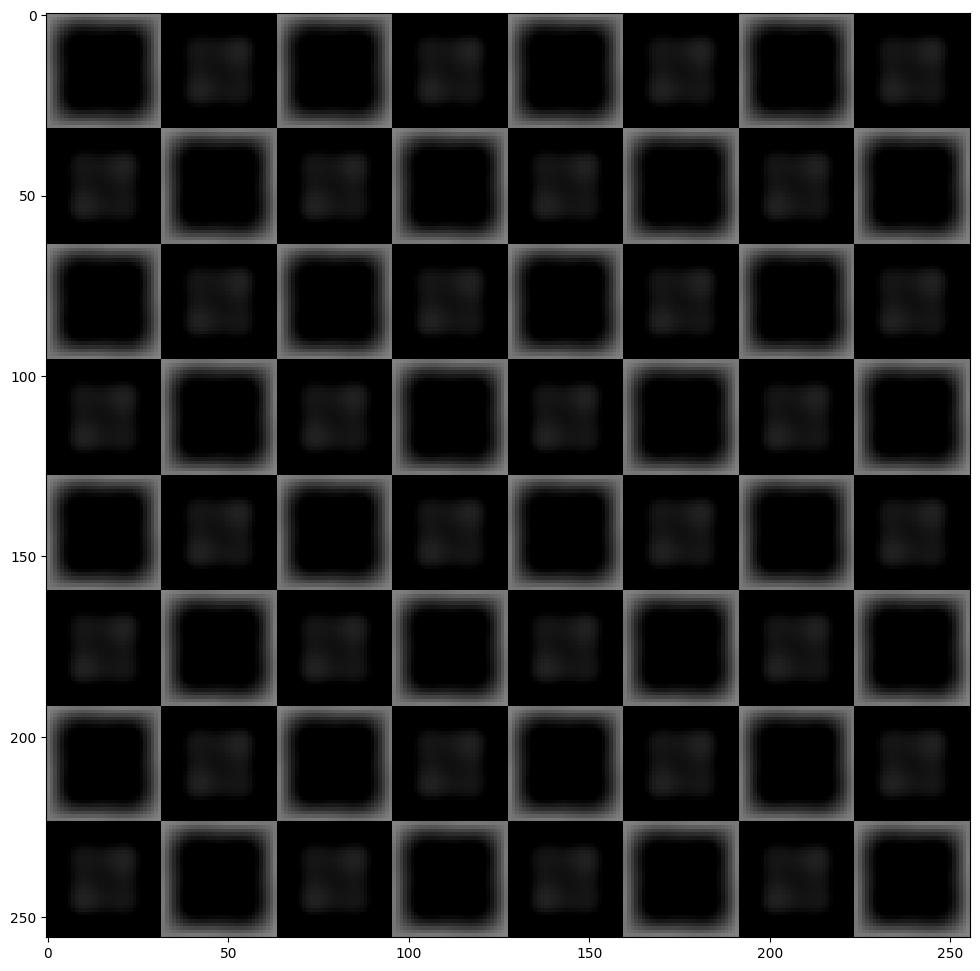

In [36]:
# remove the low frequencies of the chess board
chess_high_feq = high_pass(chess_board_ft, 12)
inv_dft_and_plot(chess_high_feq)

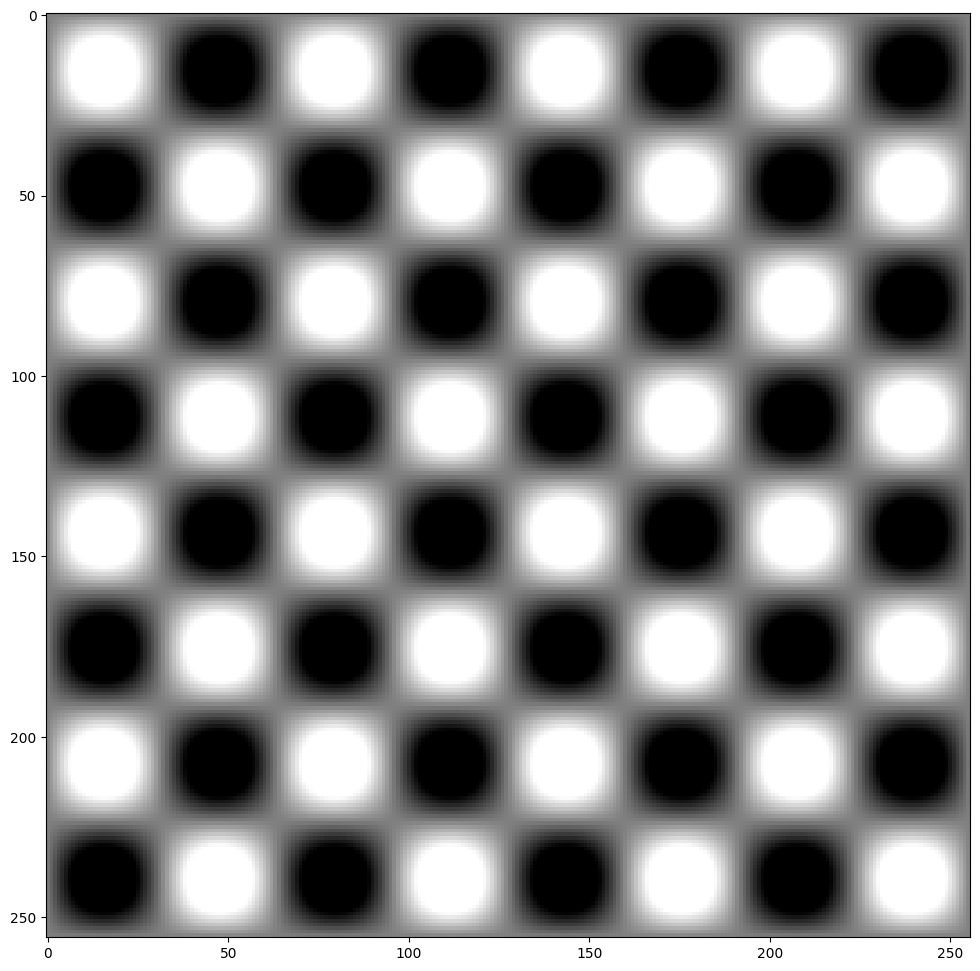

In [37]:
# remove the high frequencies of the chess board
chess_low_feq = low_pass(chess_board_ft, 10)
inv_dft_and_plot(chess_low_feq)

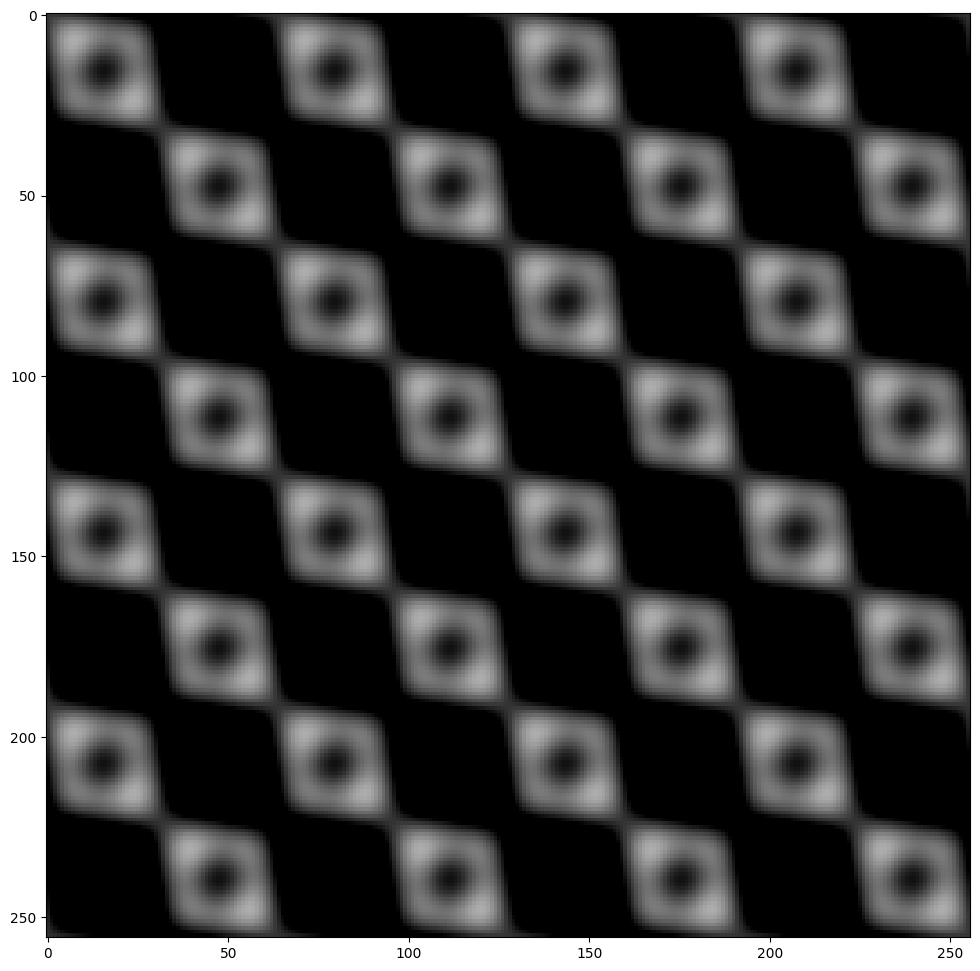

In [38]:
# remove the high frequencies of the chess board
chess_medium_feq = band_pass(chess_board_ft, 5, 15)
inv_dft_and_plot(chess_medium_feq)

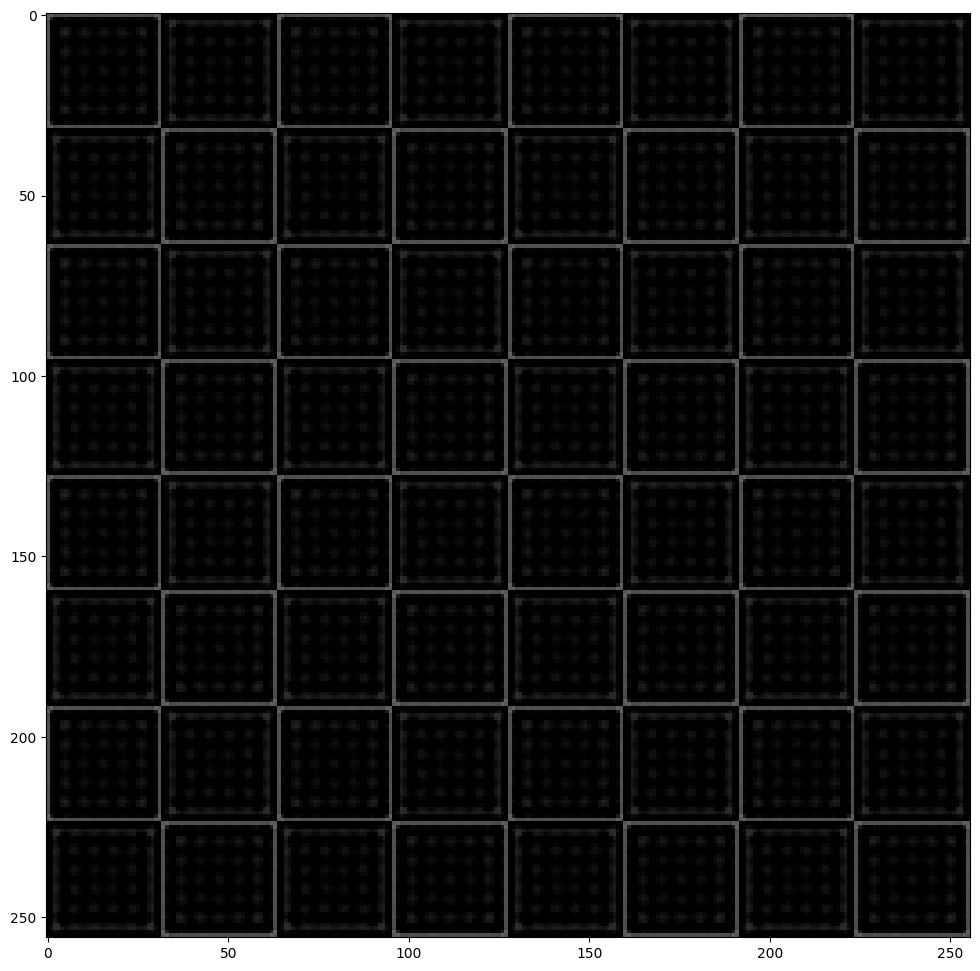

In [40]:
img = rgb2gray(chelsea() / 255)
# filter all frequencies corresponding to the coefficients between 48 and 128.
img_adjusted = band_pass(chess_board_ft, 48, 128)

inv_dft_and_plot(img_adjusted)

# Exercise 3 - FFT - 5 Points

Implement the fast fourier transformation. 
Use the [Cooley-Tukey](https://en.wikipedia.org/wiki/Cooley%E2%80%93Tukey_FFT_algorithm) algorithm.

In [52]:
def fft(x, return_shifted=False):
    """
    Computes the fast fourier transformation of x.
    """
    def next_pow2(n): return 1 << (n - 1).bit_length()
    def fft1d(v):
        v = np.asarray(v, dtype=complex)
        n = v.size
        if n == 1: return v
        if n & 1:
            k = np.arange(n); m = k.reshape((n,1))
            return np.exp(-2j*np.pi*m*k/n) @ v
        e = fft1d(v[0::2]); o = fft1d(v[1::2])
        w = np.exp(-2j*np.pi*np.arange(n)/n)
        return np.concatenate((e + w[:n//2]*o, e + w[n//2:]*o))
    a = np.asarray(x, dtype=complex)
    M0, N0 = a.shape
    M = next_pow2(M0) if (M0 & (M0-1)) else M0
    N = next_pow2(N0) if (N0 & (N0-1)) else N0
    p = np.zeros((M, N), dtype=complex)
    p[:M0, :N0] = a
    for i in range(M):
        p[i, :] = fft1d(p[i, :])
    p = p.T
    for i in range(N):
        p[i, :] = fft1d(p[i, :])
    res = p.T
    return np.fft.fftshift(res) if return_shifted else res

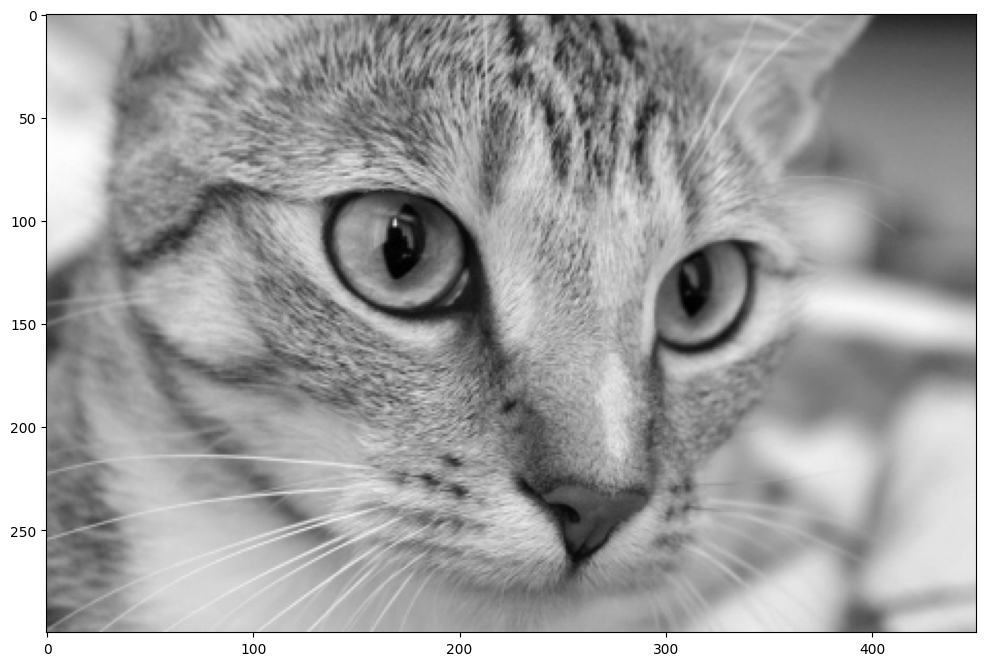

In [56]:
img = rgb2gray(chelsea() / 255.)
fft_img = fft(img)
plt.imshow(img, cmap='gray')
plt.show()

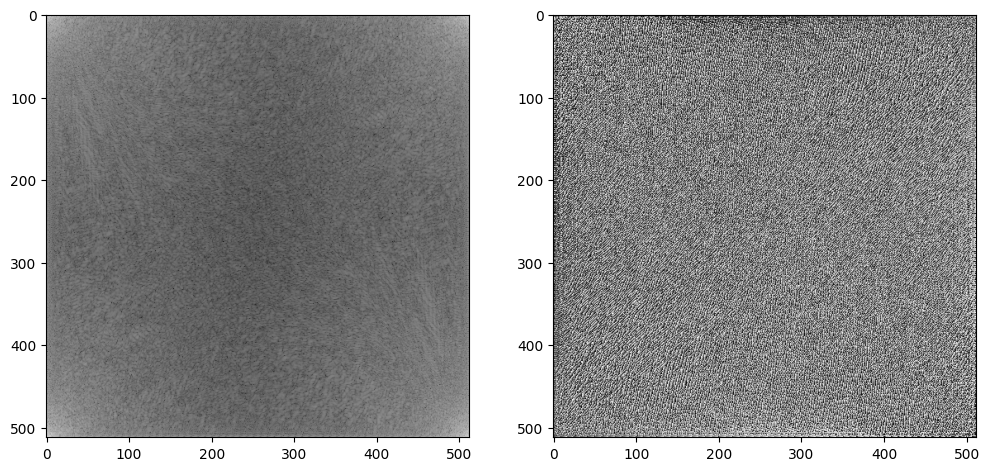

In [57]:
plt.subplot(121)

plt.imshow(np.log10(1e-9 + np.abs(fft_img)), cmap='gray')
plt.subplot(122)
plt.imshow(np.arctan2(np.imag(fft_img), np.real(fft_img)), cmap='gray')
plt.show()

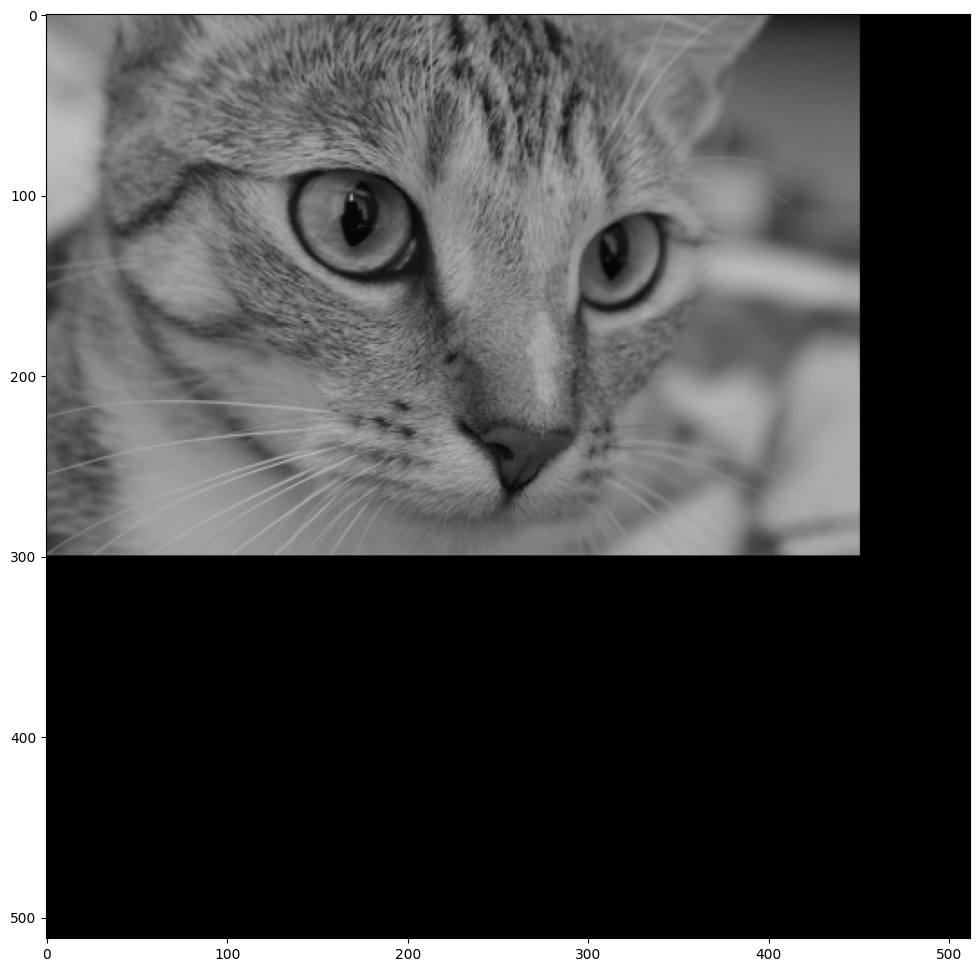

In [58]:
plt.imshow(np.real(inv_dft2d(fft_img)),cmap="gray", vmin=0, vmax=1)
plt.show()